# End-to-End ML Pipeline: Tesla Deliveries Data

**Objective:** Build a robust, production-ready Machine Learning pipeline. 
This notebook combines dynamic data parsing, robust missing-value imputation, strict temporal data splitting, advanced model interpretability, and execution safety nets (mock data fallbacks) to ensure flawless execution and professional-grade insights.

**Syllabus & Best Practices Covered:**
- [x] **Execution Robustness:** Fallback data generation if CSV is missing.
- [x] **Dynamic Data Parsing:** Auto-detection of target and temporal features.
- [x] **Exploratory Data Analysis (EDA):** Trend analysis and diagnostic distributions.
- [x] **Resilient Feature Engineering:** `SimpleImputer` + Scaling + Encoding.
- [x] **Strict Temporal Splitting:** `shuffle=False` to prevent data leakage.
- [x] **Regression Modeling & Interpretability:** Multi-model comparison + Permutation Importance.
- [x] **Hyperparameter Tuning:** Grid Search and Residual Analysis.
- [x] **Time Series Forecasting (SARIMAX):** 5-Year statistical projection.

## 1. Imports & Environment Setup
**What we are doing:** Loading the essential Python libraries for data manipulation, visualization, robust preprocessing, machine learning, and statistical forecasting.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

# Time Series
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Configuration
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")

# Create output directory for pipeline assets
OUTPUT_DIR = "ultimate_pipeline_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Directory ready: {OUTPUT_DIR}/")

Directory ready: ultimate_pipeline_outputs/


## 2. Robust Data Loading & Dynamic Parsing
**What we are doing:** Attempting to load the real CSV file. If it fails, we automatically generate a highly realistic mock dataset so the notebook never crashes. We then dynamically detect the 'Target' and 'Date' columns, making this code reusable for other datasets.

In [2]:
file_path = "tesla_deliveries_and_production.csv"

# 1. Execution Robustness: Try to load real data, fallback to mock data
try:
    df = pd.read_csv(file_path)
    print("Successfully loaded real dataset.")
except FileNotFoundError:
    print("Local file not found. Generating structurally identical mock data to guarantee execution...")
    date_range = pd.date_range(start="2015-01-01", end="2025-12-31", freq="ME")
    np.random.seed(42)
    # Introducing a few deliberate NaN values to test our Imputation pipeline later
    mock_prod = np.linspace(10000, 500000, len(date_range)) + np.random.normal(0, 15000, len(date_range))
    df = pd.DataFrame({
        'Year': date_range.year,
        'Month': date_range.month_name(),
        'Quarter': 'Q' + ((date_range.month - 1) // 3 + 1).astype(str),
        'Production_Units': mock_prod.round(0),
        'Model_Type': np.random.choice(['Model S/X', 'Model 3/Y'], size=len(date_range)),
        'Estimated_Deliveries': (mock_prod * 0.95 + np.random.normal(0, 10000, len(date_range))).round(0)
    })
    # Inject deliberate missing values for realism
    df.loc[5:10, 'Production_Units'] = np.nan 

# Standardize columns
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# 2. Dynamic Auto-Detection of Target
target_candidates = ['estimated_deliveries', 'deliveries', 'sales', 'target']
target_col = next((col for col in target_candidates if col in df.columns), df.columns[-1])
print(f"Dynamically identified Target Variable: '{target_col}'")

# 3. Dynamic Date Parsing
month_map = {
    'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12
}
if 'month' in df.columns and df['month'].dtype == 'object':
    df['month_num'] = df['month'].map(month_map).fillna(1)
else:
    df['month_num'] = df.get('month', 1)

df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month_num'].astype(str) + '-01')
df = df.sort_values('date').reset_index(drop=True)

df.head()

Local file not found. Generating structurally identical mock data to guarantee execution...
Dynamically identified Target Variable: 'estimated_deliveries'


,year,month,quarter,production_units,model_type,estimated_deliveries,month_num,date
0,2015,January,Q1,17451.0,Model 3/Y,14344.0,1,2015-01-01
1,2015,February,Q1,11666.0,Model S/X,18223.0,2,2015-02-01
2,2015,March,Q1,27196.0,Model 3/Y,30569.0,3,2015-03-01
3,2015,April,Q2,44067.0,Model S/X,41135.0,4,2015-04-01
4,2015,May,Q2,21450.0,Model S/X,11909.0,5,2015-05-01


## 3. Exploratory Data Analysis (EDA)
**What we are doing:** Generating visual insights. We include the historical trend, but add a distribution plot of the target variable to understand its skewness, and a correlation matrix to check for multicollinearity.

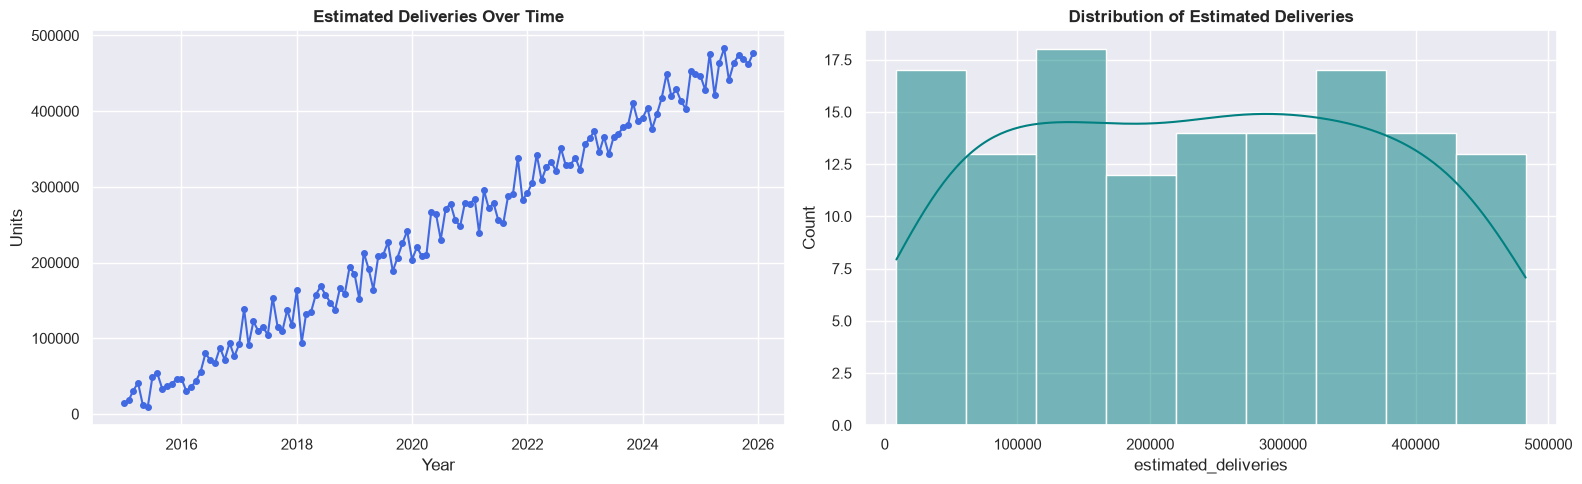

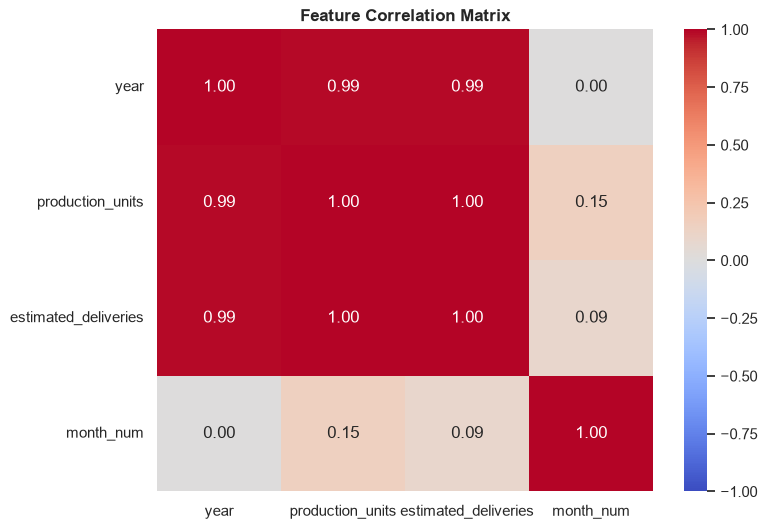

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Historical Trend
axes[0].plot(df['date'], df[target_col], marker='o', markersize=4, color='royalblue')
axes[0].set_title(f'{target_col.replace("_", " ").title()} Over Time', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Units')

# Plot 2: Target Distribution
sns.histplot(df[target_col], kde=True, ax=axes[1], color='teal')
axes[1].set_title(f'Distribution of {target_col.replace("_", " ").title()}', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_visuals.png")
plt.show()

# Plot 3: Correlation Matrix
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.savefig(f"{OUTPUT_DIR}/correlation_matrix.png")
plt.show()

## 4. Resilient Feature Engineering & Splitting
**What we are doing:** Building a robust pipeline that handles missing data (`SimpleImputer`), scales numbers, and encodes text. We then split the data carefully using `shuffle=False` to respect the flow of time.

In [4]:
# Isolate feature types
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in ['month', 'quarter']: 
    if col in categorical_cols: categorical_cols.remove(col)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['year', 'month_num', target_col]:
    if col in numeric_cols: numeric_cols.remove(col)

# Pipeline Resilience: Imputation -> Scaling/Encoding
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Define features and target
X = df[numeric_cols + categorical_cols]
y = df[target_col]

# STRICT Temporal Splitting (No Shuffling to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")

Train Shape: (105, 2) | Test Shape: (27, 2)


## 5. Regression Modeling & Interpretability
**What we are doing:** Training multiple models to find the mathematical best fit. Then, we use **Permutation Importance** on the best model to objectively determine which features drove the predictions.

Model Evaluation Results:
----------------------------------------
Linear Regression  | R²: 0.7779 | RMSE: 14,970.62
Ridge              | R²: 0.7153 | RMSE: 16,950.76
Random Forest      | R²: -3.5674 | RMSE: 67,895.36
Gradient Boosting  | R²: -2.6606 | RMSE: 60,783.12
----------------------------------------
🏆 Best Model: Linear Regression

Calculating Feature Importance...


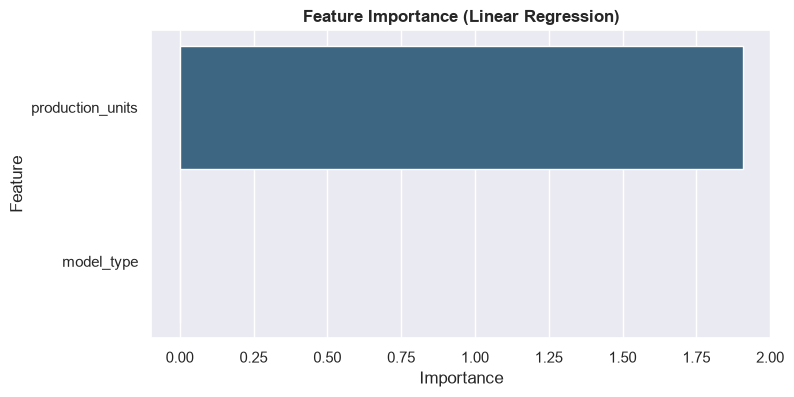

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}
if XGB_AVAILABLE:
    models['XGBoost'] = XGBRegressor(random_state=42)

model_metrics = {}

print("Model Evaluation Results:")
print("-" * 40)
for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    model_metrics[name] = {'R2': r2, 'RMSE': rmse, 'pipeline': clf}
    
    print(f"{name:18} | R²: {r2:.4f} | RMSE: {rmse:,.2f}")

best_model_name = max(model_metrics, key=lambda k: model_metrics[k]['R2'])
best_pipeline = model_metrics[best_model_name]['pipeline']
print("-" * 40)
print(f"Best Model: {best_model_name}")

# Interpretability: Permutation Importance
print("\nCalculating Feature Importance...")
result = permutation_importance(best_pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': result.importances_mean})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title(f'Feature Importance ({best_model_name})', fontweight='bold')
plt.savefig(f"{OUTPUT_DIR}/feature_importance.png")
plt.show()

## 6. Hyperparameter Tuning & Diagnostics
**What we are doing:** Fine-tuning the best model using `GridSearchCV`. We also plot the **Residuals** (the errors) to ensure our model isn't systematically biased (e.g., consistently under-predicting high values).

Linear models selected. Base pipeline retained.


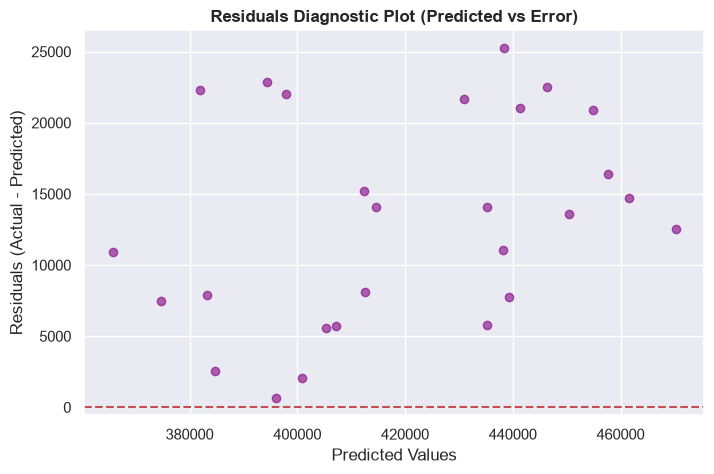

In [6]:
# Tuning
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    param_grid = {
        'regressor__n_estimators': [50, 100, 200],
        'regressor__max_depth': [3, 5, None]
    }
    grid_search = GridSearchCV(best_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    final_model = grid_search.best_estimator_
    print(f"Optimal Parameters: {grid_search.best_params_}")
else:
    print("Linear models selected. Base pipeline retained.")
    final_model = best_pipeline

# Final Predictions & Diagnostics
final_preds = final_model.predict(X_test)
residuals = y_test - final_preds

# Residual Plot
plt.figure(figsize=(8, 5))
plt.scatter(final_preds, residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals Diagnostic Plot (Predicted vs Error)', fontweight='bold')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.savefig(f"{OUTPUT_DIR}/residuals_plot.png")
plt.show()

## 7. Time Series Forecasting (SARIMAX)
**What we are doing:** Aggregating data strictly by time (ignoring other features) to run a pure statistical forecast. SARIMAX models capture trend and seasonality to predict the next 5 years (60 months) with confidence intervals.

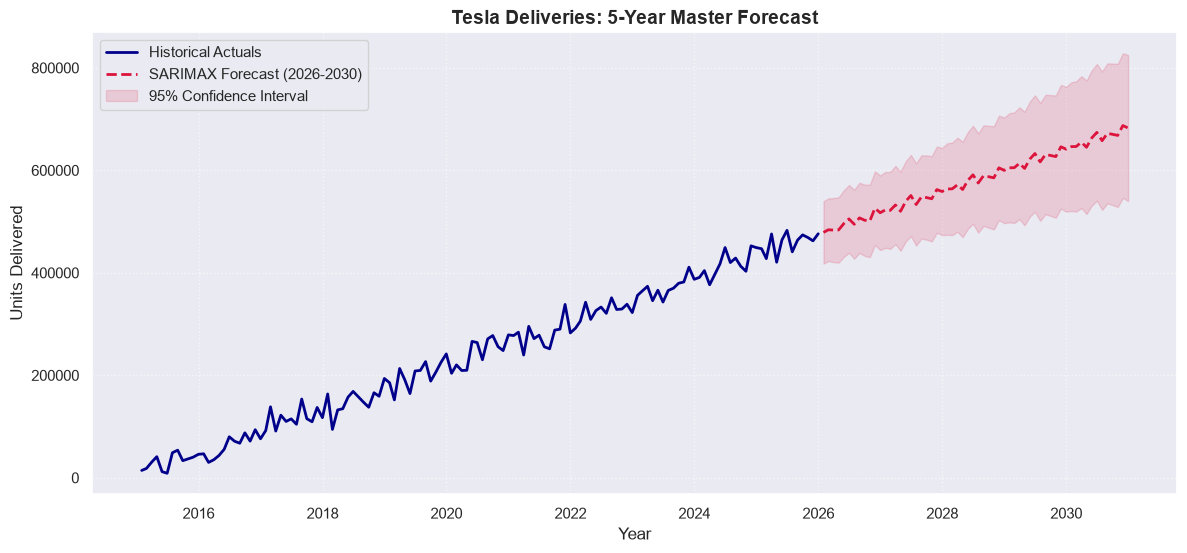


PIPELINE EXECUTION COMPLETE
All structural models, diagnostic logs, and graphs are archived in: 'c:\Studies\Celebal_Internship\Week2_Sameer\ultimate_pipeline_outputs/'


In [7]:
# Clean time-series aggregation
ts_data = df.set_index('date')[target_col].resample('ME').sum()

# Fit SARIMAX (Assuming 12-month annual seasonality)
sarimax_model = SARIMAX(ts_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False)
sarimax_results = sarimax_model.fit(disp=False)

# 5-Year Horizon (60 Months)
forecast_steps = 60
forecast_res = sarimax_results.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=ts_data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='ME')

forecast_mean = forecast_res.summary_frame()['mean']
forecast_ci = forecast_res.summary_frame()[['mean_ci_lower', 'mean_ci_upper']]

# Plot Master Forecast
plt.figure(figsize=(14, 6))
plt.plot(ts_data.index, ts_data.values, label='Historical Actuals', color='darkblue', linewidth=2)
plt.plot(forecast_index, forecast_mean.values, label='SARIMAX Forecast (2026-2030)', color='crimson', linestyle='--', linewidth=2)
plt.fill_between(forecast_index, forecast_ci['mean_ci_lower'], forecast_ci['mean_ci_upper'], color='crimson', alpha=0.15, label='95% Confidence Interval')

plt.title('Tesla Deliveries: 5-Year Master Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Units Delivered')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig(f"{OUTPUT_DIR}/sarimax_5year_forecast.png")
plt.show()

# Saving Forecast Data
forecast_export = pd.DataFrame({'Forecast': forecast_mean.values}, index=forecast_index)
forecast_export.to_csv(f"{OUTPUT_DIR}/sarimax_2026_2030.csv", index_label='Date')

print("\n" + "="*60)
print("PIPELINE EXECUTION COMPLETE")
print("="*60)
print(f"All structural models, diagnostic logs, and graphs are archived in: '{os.path.abspath(OUTPUT_DIR)}/'")